<a href="https://colab.research.google.com/github/miguel05mex78-bot/DataScienceMastery/blob/main/Advanced%2BApplication%2Bin%2BFinancesTeslaStockAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Objective: Use optuna library and yahoo finances API to predict the price of Tesla stock value using an optimized LSTM neural network.


#**Prepare environment**

## Install reqiured libraries and call modules

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from random import sample
from datetime import timedelta
from itertools import cycle
from skopt import BayesSearchCV
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from skopt.plots import plot_objective, plot_convergence
from sklearn.ensemble import GradientBoostingRegressor
# In Colab Notebooks, we have to install scikit-optimize and optuna:
!pip install scikit-optimize
!pip install optuna







##Functions to evaluate regression performance (MAE, MSE, RMSE, R2)

In [ ]:
def evaluate_regression_performance(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    mask = y_true != 0
    mape = np.mean(np.abs((y_true - y_pred) / y_true)[mask]) * 100

    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.4f}")
    print(f"Rsq: {r2:.4f}")

#**Finances**

## Data preparation

In [ ]:
# Download stock data from Yahoo Finance
ticker = "TSLA"
price_type = 'Close'
start_date = "2010-01-01"
end_date = "2023-11-01"
data = yf.download(ticker, start = start_date, end = end_date)

# Feature engineering: Creating additional temporal features
data['Date'] = data.index
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day
data['DayOfWeek'] = data['Date'].dt.dayofweek

# Define features and target variable
features = ['Year', 'Month', 'Day', 'DayOfWeek']
target = price_type  # Predicting closing stock price

X = data[features]
y = data[target]
print(y)
print(type(y))
# But sklearn models expect a Series or 1-D array.
y = data[target].values.ravel()


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Sort the X_test index
X_test_sorted = X_test.sort_index()

/tmp/ipykernel_831/288067389.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start = start_date, end = end_date)
[*********************100%***********************]  1 of 1 completed

Ticker            TSLA
Date                  
2010-06-29    1.592667
2010-06-30    1.588667
2010-07-01    1.464000
2010-07-02    1.280000
2010-07-06    1.074000
...                ...
2023-10-25  212.419998
2023-10-26  205.759995
2023-10-27  207.300003
2023-10-30  197.360001
2023-10-31  200.839996

[3359 rows x 1 columns]
<class 'pandas.core.frame.DataFrame'>


## Data exploration

In [ ]:
data.describe()

Price,Close,High,Low,Open,Volume,Date,Year,Month,Day,DayOfWeek
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,,,,,
count,3359.000000,3359.000000,3359.000000,3359.000000,3.359000e+03,3359,3359.000000,3359.000000,3359.000000,3359.000000
mean,68.428702,69.974238,66.812905,68.452214,9.652291e+07,2017-02-27 16:41:00.732360960,2016.654361,6.595415,15.747544,2.024710
min,1.053333,1.108667,0.998667,1.076000,1.777500e+06,2010-06-29 00:00:00,2010.000000,1.000000,1.000000,0.000000
25%,10.163333,10.516000,9.952666,10.228333,4.551450e+07,2013-10-28 12:00:00,2013.000000,4.000000,8.000000,1.000000
50%,16.815332,17.049999,16.566668,16.804001,8.051580e+07,2017-03-01 00:00:00,2017.000000,7.000000,16.000000,2.000000
75%,73.314667,74.100666,69.474335,69.859333,1.231410e+08,2020-06-30 12:00:00,2020.000000,10.000000,23.000000,3.000000
max,409.970001,414.496674,405.666656,411.470001,9.140820e+08,2023-10-31 00:00:00,2023.000000,12.000000,31.000000,4.000000
std,100.373623,102.723203,97.965926,100.458809,8.046433e+07,NaN,3.867124,3.400818,8.758760,1.398858


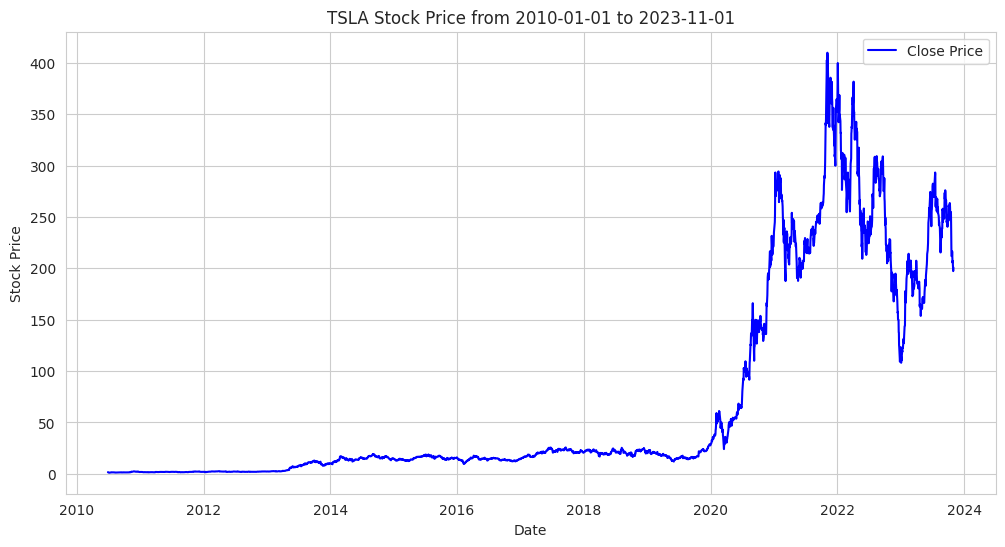

In [ ]:
# Visualize Stock Price
plt.figure(figsize=(12, 6))
plt.plot(data.index, data[price_type], label= f'{price_type} Price', color='blue')
plt.title(f'{ticker} Stock Price from {start_date} to {end_date}')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

/tmp/ipykernel_831/1831151462.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data[price_type], shade=True, color='blue')


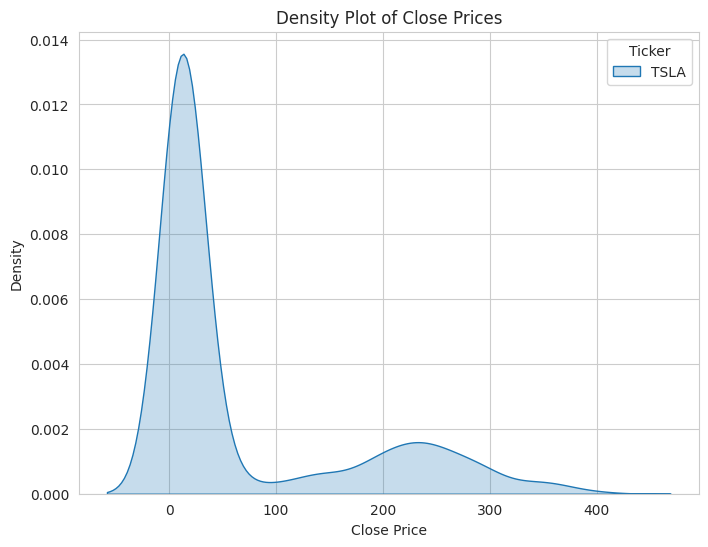

In [ ]:
# Set the style of the plot
sns.set_style("whitegrid")

# Create the density plot
plt.figure(figsize=(8, 6))
sns.kdeplot(data[price_type], shade=True, color='blue')
plt.title(f'Density Plot of {price_type} Prices')
plt.xlabel(f'{price_type} Price')
plt.ylabel('Density')
plt.show()

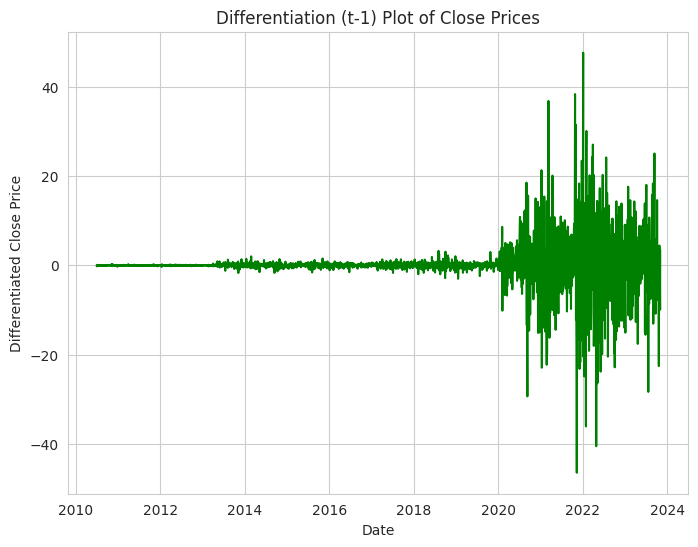

In [ ]:
# Calculate the differentiation (t-1) of the series
differentiated_series = data[price_type] - data[price_type].shift(1)

# Plot the differentiated series
plt.figure(figsize=(8, 6))
plt.plot(data.index, differentiated_series, color='green')
plt.title(f'Differentiation (t-1) Plot of {price_type} Prices')
plt.xlabel('Date')
plt.ylabel(f'Differentiated {price_type} Price')
plt.show()

## GRADIENT BOOSTING

### Bayesian Optimization of Gradient Boosting

<Axes: >

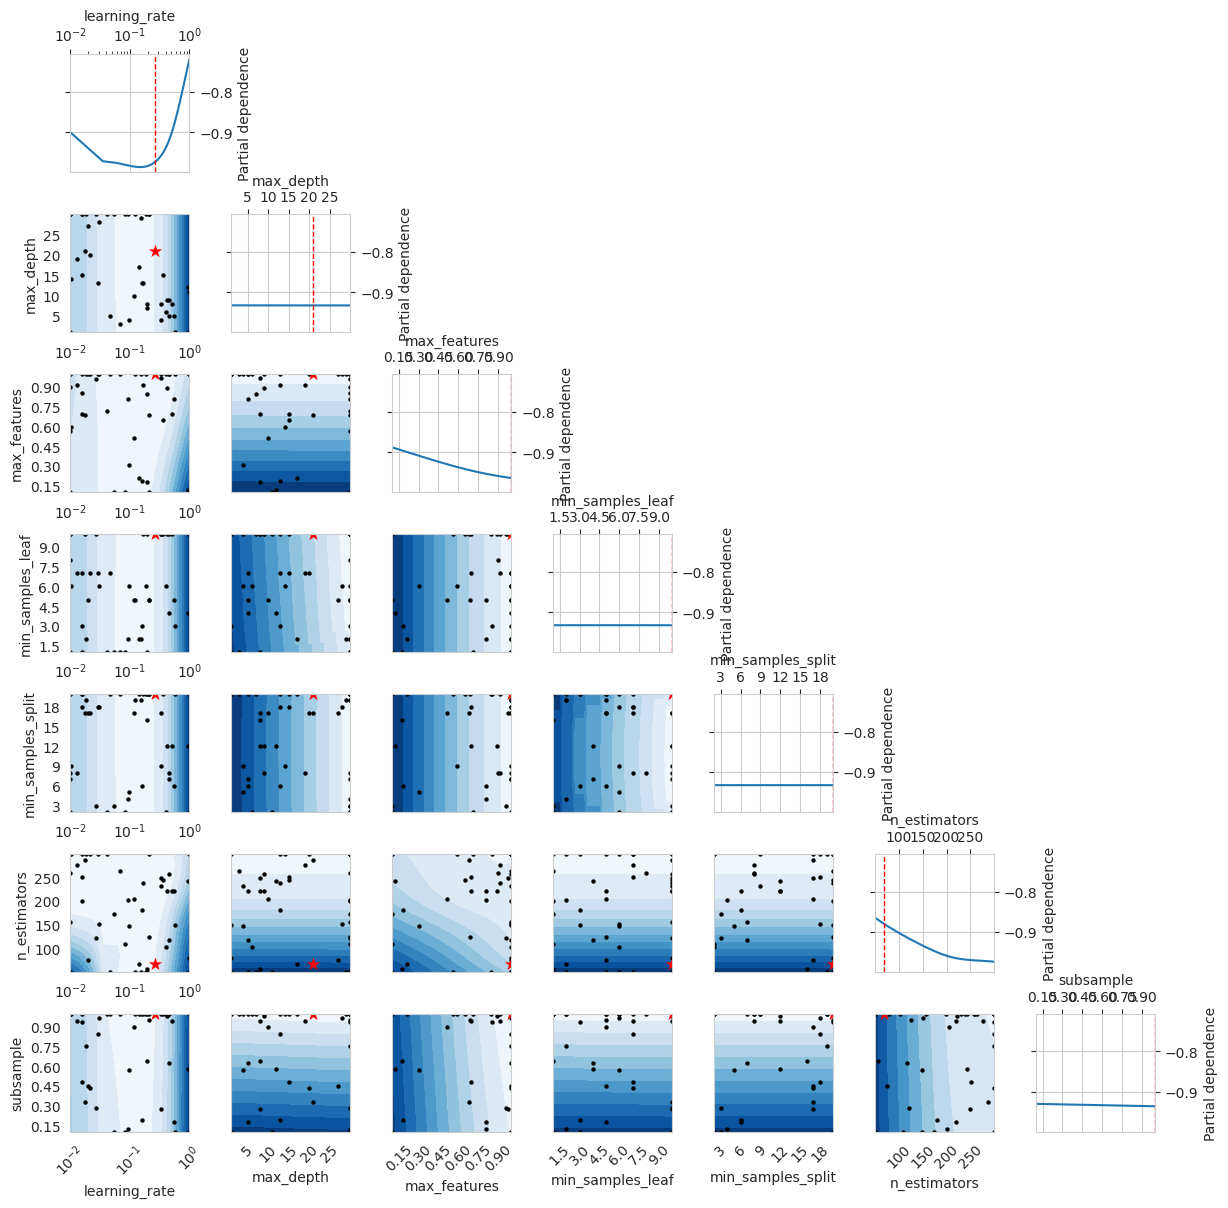

In [ ]:
param_space_gb =  {
    'learning_rate': (0.01, 1.0, 'log-uniform'),
    'n_estimators': (50, 300),
    'max_depth': (1, 30),
    'min_samples_split': (2, 20),
    'min_samples_leaf': (1, 10),
    'subsample': (0.1, 1.0, 'uniform'),
    'max_features': (0.1, 1.0, 'uniform')
}

# Initialize XGBoost Regressor
model_gb = GradientBoostingRegressor(criterion='squared_error', random_state=42)

# Initialize BayesSearchCV
opt = BayesSearchCV(model_gb, param_space_gb, n_iter=50, cv=5, n_jobs=-1)

# Fit the model
opt.fit(X_train, y_train)

# Get the best hyperparameters
best_params = opt.best_params_


# from skopt.plots import plot_objective, plot_convergence
plot_objective(opt.optimizer_results_[0], cmap='Blues')

### Gradient Boosting without optimization for regression

In [65]:
# Train the model with the best hyperparameters
# The error occurs because y_test is a NumPy array, and you are trying to index it using X_test_sorted.index (a pandas DatetimeIndex). NumPy arrays only accept integer positions, not pandas indexes.

# Train the model
best_model_gb = GradientBoostingRegressor(criterion='squared_error', **best_params)
best_model_gb.fit(X_train, y_train)

# Predict
y_pred_sorted_best_gb_model = best_model_gb.predict(X_test_sorted)

# Convert y_test to pandas Series with the correct index
y_test_series = pd.Series(y_test, index=X_test.index)

# Align with sorted X_test
y_test_sorted = y_test_series.loc[X_test_sorted.index]

# Performance metrics
evaluate_regression_performance(y_test_sorted, y_pred_sorted_best_gb_model)

MAE: 2.7745
MSE: 39.4590
RMSE: 6.2816
MAPE: 5.7415
Rsq: 0.9956


In [67]:
# The error comes from a shape mismatch between y_true and y_pred.
# Specifically, y_true is likely 2-D (shape (n,1)) while y_pred is 1-D (shape (n,)). When the mask y_true != 0 is applied, NumPy raises the boolean indexing error.

# Also in your traceback you used y_pred_sorted_gb_base instead of y_pred_sorted_best_gb_model, which may not correspond to the predictions you just created.

# Train the model
best_model_gb = GradientBoostingRegressor(criterion='squared_error', **best_params)
best_model_gb.fit(X_train, y_train)

# Predict
y_pred_sorted_best_gb_model = best_model_gb.predict(X_test_sorted)

# Convert y_test to pandas Series with correct index
y_test_series = pd.Series(y_test.ravel(), index=X_test.index)

# Align with sorted X_test
y_test_sorted = y_test_series.loc[X_test_sorted.index]

# Convert to numpy 1D arrays
y_true_for_evaluation = y_test_sorted.values.ravel()
y_pred_for_evaluation = y_pred_sorted_best_gb_model.ravel()

# Performance metrics
evaluate_regression_performance(y_true_for_evaluation, y_pred_for_evaluation)



MAE: 2.7745
MSE: 39.4590
RMSE: 6.2816
MAPE: 5.7415
Rsq: 0.9956


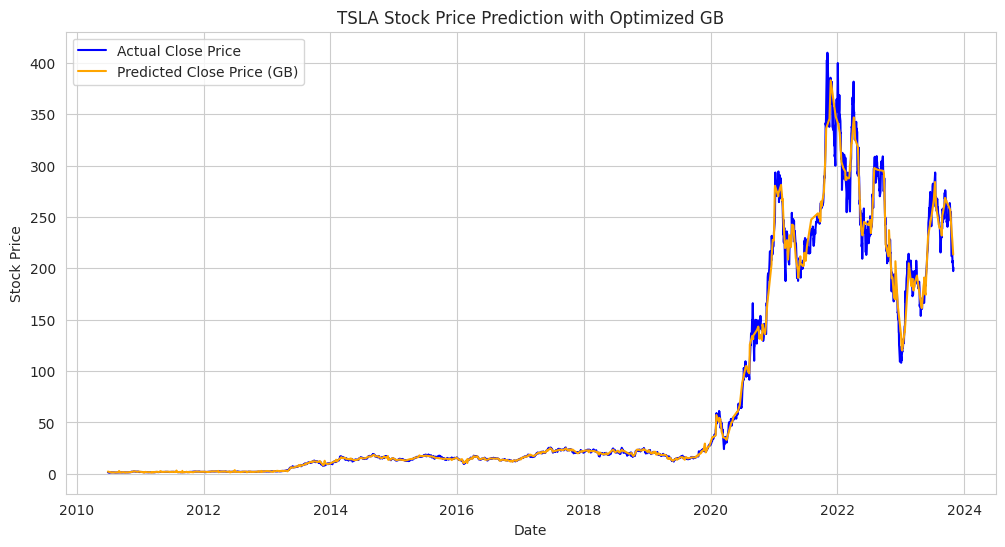

In [68]:
# Visualize predictions
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label='Actual Close Price', color='blue')
plt.plot(X_test_sorted.index, y_pred_sorted_best_gb_model, label='Predicted Close Price (GB)', color='orange')
plt.title(f'{ticker} Stock Price Prediction with Optimized GB')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(


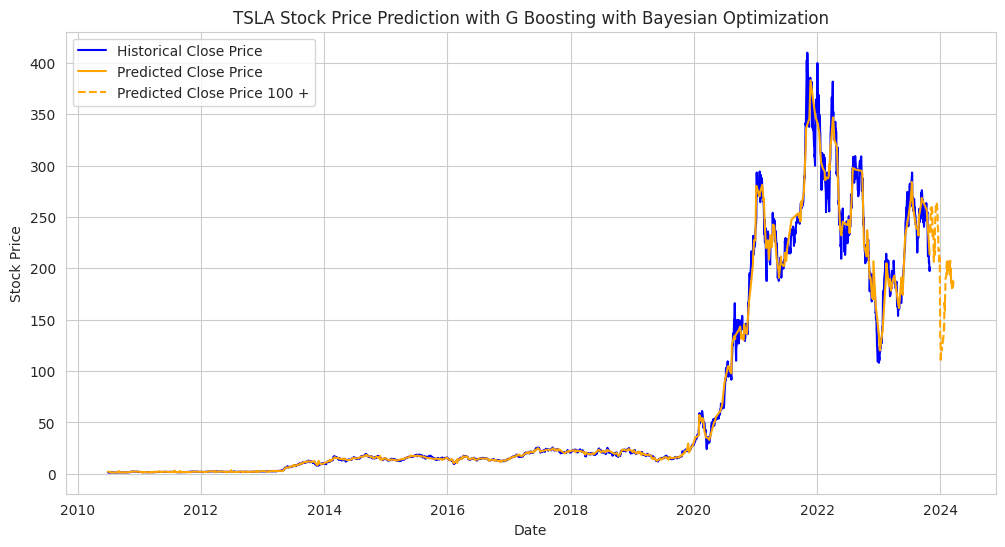

In [69]:
# Generate future dates for prediction
future_dates = pd.date_range(start=data.index[-1] + timedelta(days=1), periods=100, freq='B')  # Predicting for the next 30 business days

# Create a DataFrame with future dates and temporal features
future_features = pd.DataFrame({'Year': future_dates.year,
                                'Month': future_dates.month,
                                'Day': future_dates.day,
                                'DayOfWeek': future_dates.dayofweek})

# Make predictions for future dates using the trained XGBoost model
future_predictions_gb = best_model_gb.predict(future_features)

# Visualize predictions
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label='Historical Close Price', color='blue')
plt.plot(X_test_sorted.index, y_pred_sorted_best_gb_model, label='Predicted Close Price', color='orange')
plt.plot(future_dates, future_predictions_gb, label='Predicted Close Price 100 +', color='orange', linestyle='--')
plt.title(f'{ticker} Stock Price Prediction with G Boosting with Bayesian Optimization')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

## **XTREME GRADIENT BOOSTING**



### XGB without optimization

In [71]:
# The new error occurs because y_test is a NumPy array, and you are trying to index it using X_test_sorted.index, which is a pandas index. NumPy arrays only accept integer positions, not pandas indices

# Train the model
best_model_gb = GradientBoostingRegressor(criterion='squared_error', **best_params)
best_model_gb.fit(X_train, y_train)

# Predict
y_pred_sorted_best_gb_model = best_model_gb.predict(X_test_sorted)

# Convert y_test to pandas Series with correct index
y_test_series = pd.Series(y_test.ravel(), index=X_test.index)

# Align with sorted X_test
y_test_sorted = y_test_series.loc[X_test_sorted.index]

# Convert to numpy arrays
y_true_for_evaluation = y_test_sorted.values
y_pred_for_evaluation = y_pred_sorted_best_gb_model

# Performance metrics
evaluate_regression_performance(y_true_for_evaluation, y_pred_for_evaluation)

MAE: 2.7745
MSE: 39.4590
RMSE: 6.2816
MAPE: 5.7415
Rsq: 0.9956


### XGB with bayesian optimization

<Axes: >

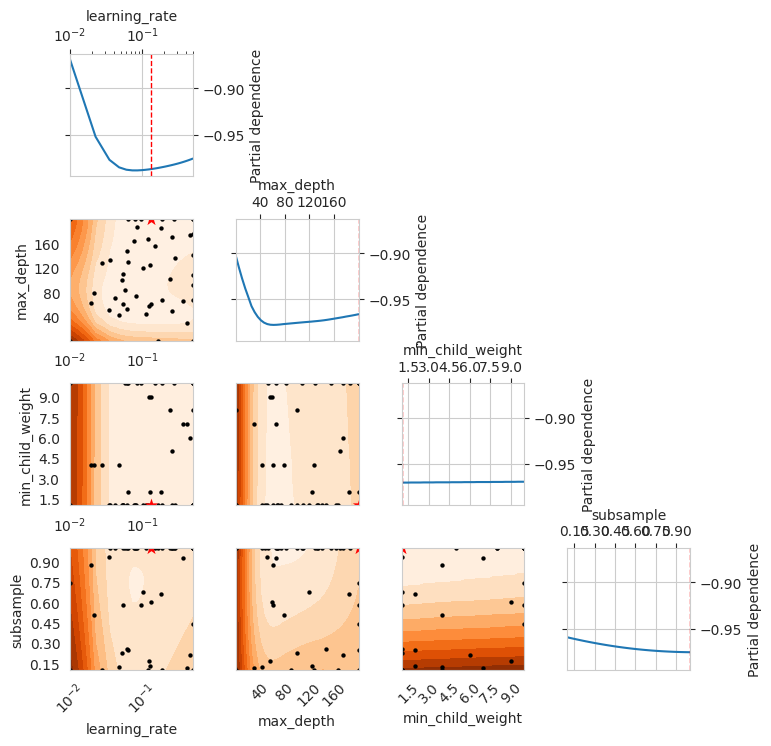

In [72]:
# Define the search space
param_space_xgb = {
    'learning_rate': (0.01, 0.5, 'log-uniform'),
    'max_depth': (1, 200),
    'min_child_weight': (1, 10),
    'subsample': (0.1, 1.0, 'uniform')
}

# Initialize XGBoost Regressor
model_xgb = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Initialize BayesSearchCV
opt = BayesSearchCV(model_xgb, param_space_xgb, n_iter=50, cv=5, n_jobs=-1)

# Fit the model
opt.fit(X_train, y_train)

# Get the best hyperparameters
best_params = opt.best_params_


plot_objective(opt.optimizer_results_[0], cmap='Oranges')

In [73]:
## The error happens because y_test is likely a NumPy array, and you are trying to index it using pandas indices (X_test_sorted.index). NumPy arrays only accept integer positions, not pandas index labels.

# Convert y_test to pandas Series if it is a numpy array
y_test = pd.Series(y_test, index=X_test.index)

# Train the model
best_model_xgb = xgb.XGBRegressor(objective='reg:squarederror', **best_params, random_state=42)
best_model_xgb.fit(X_train, y_train)

# Sort the X_test index
X_test_sorted = X_test.sort_index()

# Make predictions
y_pred_sorted_xgb = best_model_xgb.predict(X_test_sorted)

# Performance metrics
evaluate_regression_performance(y_test.loc[X_test_sorted.index], y_pred_sorted_xgb)


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

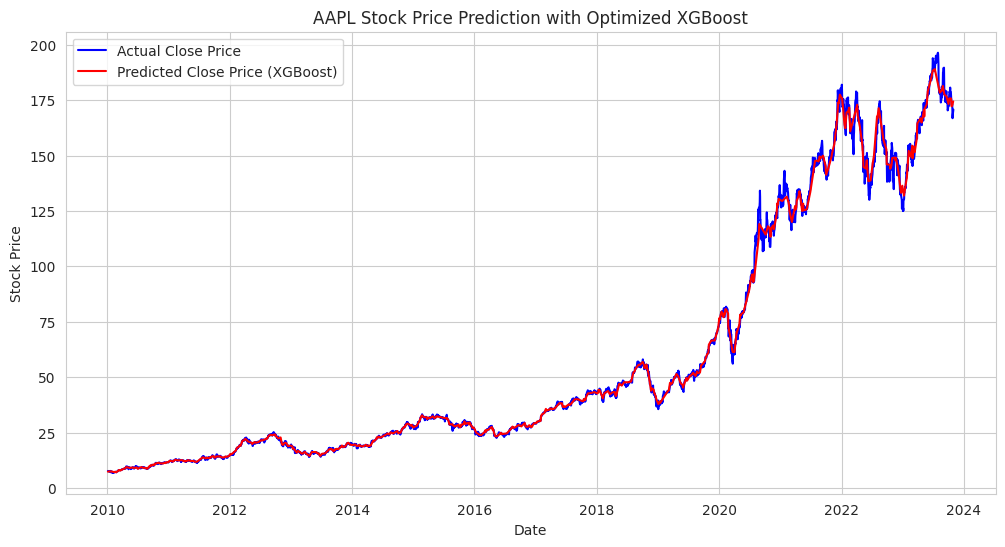

In [ ]:
# Visualize predictions
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label='Actual Close Price', color='blue')
plt.plot(X_test_sorted.index, y_pred_sorted_xgb, label='Predicted Close Price (XGBoost)', color='red')
plt.title(f'{ticker} Stock Price Prediction with Optimized XGBoost')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

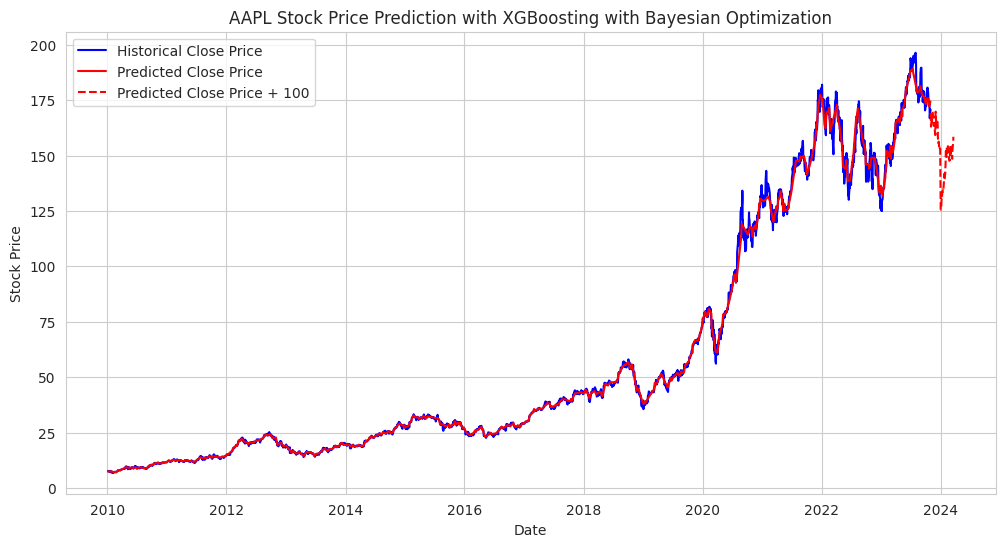

In [ ]:
# Generate future dates for prediction
future_dates = pd.date_range(start=data.index[-1] + timedelta(days=1), periods=100, freq='B')  # Predicting for the next 30 business days

# Create a DataFrame with future dates and temporal features
future_features = pd.DataFrame({'Year': future_dates.year,
                                'Month': future_dates.month,
                                'Day': future_dates.day,
                                'DayOfWeek': future_dates.dayofweek})

# Make predictions for future dates using the trained XGBoost model
future_predictions_xgb = best_model_xgb.predict(future_features)

# Visualize predictions
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label='Historical Close Price', color='blue')
plt.plot(X_test_sorted.index, y_pred_sorted_xgb, label='Predicted Close Price', color='red')
plt.plot(future_dates, future_predictions_xgb, label='Predicted Close Price + 100', color='red', linestyle='--')
plt.title(f'{ticker} Stock Price Prediction with XGBoosting with Bayesian Optimization')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

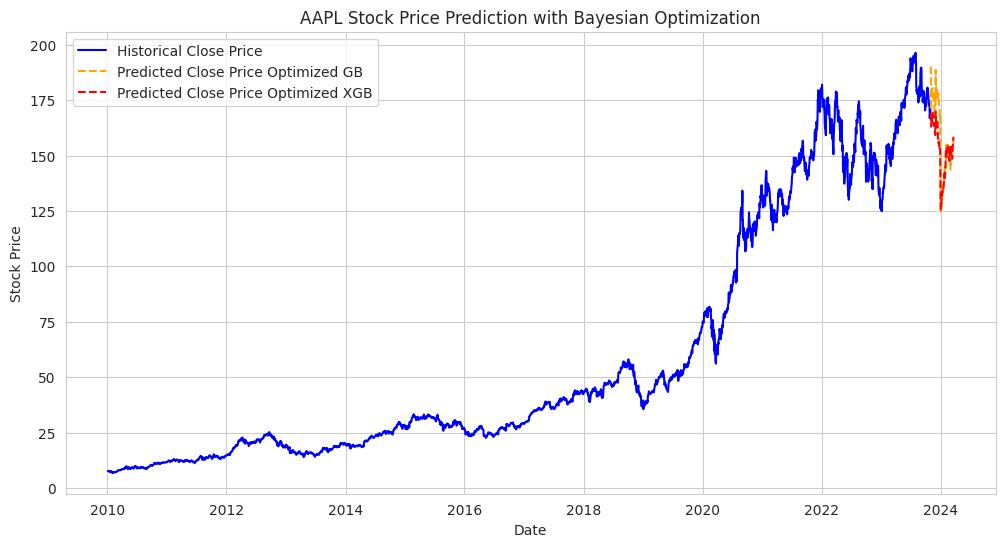

In [ ]:
# Visualize predictions
plt.figure(figsize=(12, 6))
plt.plot(data.index, data[price_type], label=f'Historical {price_type} Price', color='blue')
plt.plot(future_dates, future_predictions_gb, label=f'Predicted {price_type} Price Optimized GB', color='orange', linestyle='--')
plt.plot(future_dates, future_predictions_xgb, label=f'Predicted {price_type} Price Optimized XGB', color='red', linestyle='--')
plt.title(f'{ticker} Stock Price Prediction with Bayesian Optimization')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()